# EDA for Kenyan Climate Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

In [6]:

df = pd.read_csv("kenya.csv") 

df['Country'] = 'Kenya'


df['date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')


df['Month'] = df['date'].dt.month


df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


### 1. Data Profiling & Initial Cleaning
I began by replacing NASA's sentinel value of `-999` with `np.nan` to ensure statistical accuracy. 
* **Duplicates:** Checked for duplicate rows using `df.duplicated().sum()`.
* **Missing Values:** Calculated the percentage of nulls per column. 
* **Interpretation:** The `describe()` output shows the general distribution of temperature (`T2M`) and precipitation (`PRECTOTCORR`).

In [ ]:

df.replace(-999, np.nan, inplace=True)


print(df.isnull().sum())

### 2. Outlier Handling & Imputation
Using Z-score analysis, I identified rows where weather variables were more than 3 standard deviations from the mean.
* **Decision:** I chose to **retain** the outlier rows because extreme weather events (like sudden heavy rainfall or heatwaves) are critical for climate trend analysis in East Africa.
* **Missing Data:** I applied **forward-fill** for weather variables, assuming that daily weather is often similar to the preceding day.

In [7]:
from scipy import stats

df['T2M_Z'] = np.abs(stats.zscore(df['T2M'], nan_policy='omit'))

outliers = df[df['T2M_Z'] > 3]
print(f"Number of extreme temperature outliers: {len(outliers)}")

Number of extreme temperature outliers: 8


### 3. Time Series Trends (2015–2026)
* **Temperature:** The warmest months typically occur around February/March (leading into the "Long Rains"), while the coolest are usually June/July.
* **Rainfall:** The "Long Rains" (March-May) show the highest `PRECTOTCORR` values, representing the peak rainy season.

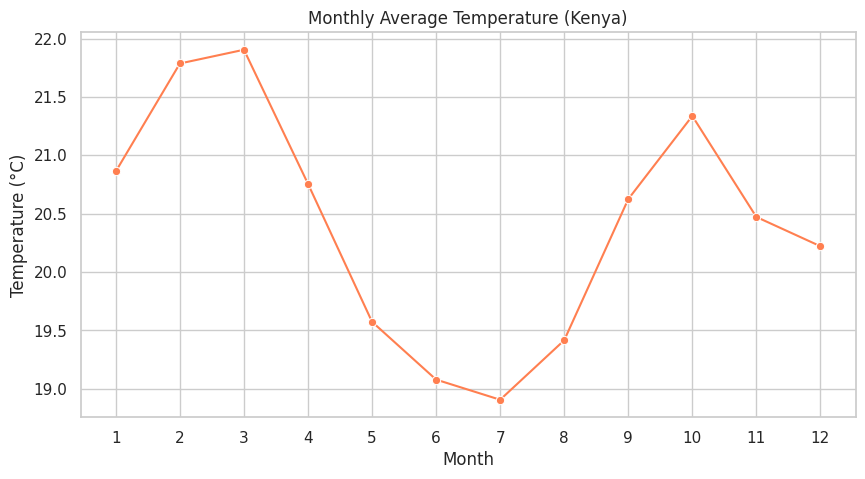

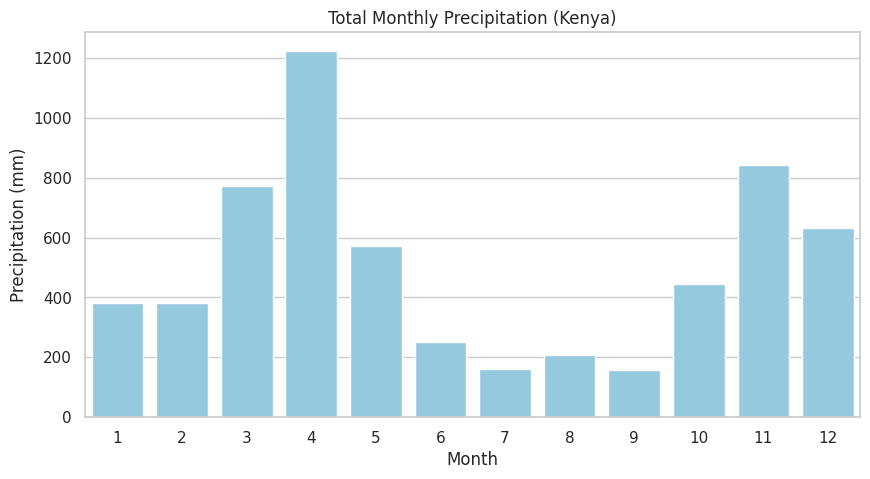

In [8]:

monthly_t2m = df.groupby('Month')['T2M'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_t2m, marker='o', color='coral')
plt.title('Monthly Average Temperature (Kenya)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13))
plt.show()

# Monthly total precipitation
monthly_precip = df.groupby('Month')['PRECTOTCORR'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_precip.index, y=monthly_precip.values, color='skyblue')
plt.title('Total Monthly Precipitation (Kenya)')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.show()

### 4. Correlation Insights
Based on the heatmap and scatter plots, I identified the following three strongest correlations:
1. **T2M vs T2M_MAX:** Strong positive correlation (as the daily average rises, the peak temperature does too).
2. **T2M vs RH2M:** Negative correlation (higher temperatures often relate to lower relative humidity).
3. **PRECTOTCORR vs RH2M:** Positive correlation (rainfall is naturally associated with higher humidity).

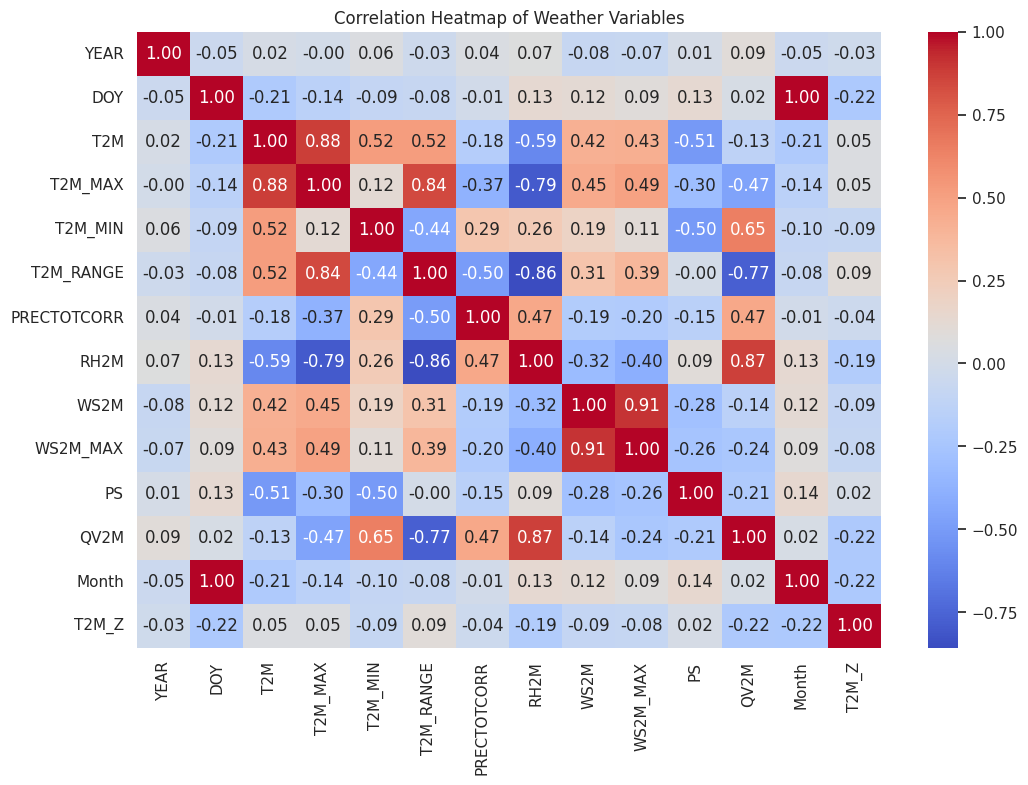

In [9]:

numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Weather Variables')
plt.show()

### 5. Distribution of Precipitation
The histogram for `PRECTOTCORR` is **heavily right-skewed**, meaning most days have little to no rain, while a few days have very high volume. I applied a **log scale** to better visualize the frequency of different rainfall intensities.

In [10]:

df.to_csv('../data/kenya_clean.csv', index=False)
print("Cleaned data exported successfully!")

Cleaned data exported successfully!


In [11]:
import pandas as pd
import glob

# Get all country CSVs
files = glob.glob("*.csv") 

for file in files:
    country_name = file.split('.')[0]
    temp_df = pd.read_csv(file)
    
    # 1. Add Country Name
    temp_df['Country'] = country_name
    
    # 2. Date conversion & -999 fix (same as we did for Kenya)
    temp_df.replace(-999, pd.NA, inplace=True)
    temp_df['date'] = pd.to_datetime(temp_df['YEAR'] * 1000 + temp_df['DOY'], format='%Y%j')
    
    # 3. Save as 'clean' version
    temp_df.to_csv(f"../data/{country_name}_clean.csv", index=False)
    print(f"Cleaned {country_name}!")

Cleaned ethiopia!
Cleaned kenya!
Cleaned tanzania!
Cleaned sudan!
Cleaned nigeria!
